In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm, LinearSegmentedColormap, Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LogNorm
import matplotlib as mpl

import torch
import dnnlib.util_v7 as util
from tqdm import tqdm
import pickle
from matplotlib.ticker import FuncFormatter
import pickle, types
from torch_utils import persistence

from PIL import Image

import numpy as np
import pickle
import os
import re 
import json 
import click
import torch
from torch_utils import distributed as dist
from training import toy_training_loop_vfm_noDataGen
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib import colors
from plot_neural_v7 import *
from plot_sim_results_v7 import *
from plot_sim_results_img_v7 import * 


import pandas as pd

import warnings
warnings.filterwarnings('ignore', 'Grad strides do not match bucket view strides') # False warning 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
colorgrad = "PuOr"

# 0. Some functions...

In [2]:
def plot_traj_3d(X):
    X = np.asarray(X)                    # (T, 3)
    T = len(X)
    t = np.arange(T)

    # line segments between consecutive points
    segs = np.stack([X[:-1], X[1:]], axis=1)   # (T-1, 2, 3)

    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(projection='3d')

    norm = mpl.colors.Normalize(vmin=0, vmax=T-1)
    cmap = plt.get_cmap()               # use current default colormap

    lc = Line3DCollection(segs, cmap=cmap, norm=norm, linewidth=2)
    lc.set_array(t[1:])                 # color by time index of segment end
    ax.add_collection3d(lc)

    # (optional) show the sampled points too
    ax.scatter(X[:,0], X[:,1], X[:,2], c=t, s=12, cmap=cmap, norm=norm)

    # nice bounds/aspect
    lo, hi = X.min(0), X.max(0)
    ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
    ax.set_box_aspect(hi - lo)

    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z'); ax.set_title('3D Trajectory (color = time)')
    fig.colorbar(lc, ax=ax, pad=0.02, fraction=0.05, label='time step')
    plt.tight_layout()
    plt.show()

In [3]:
def rotation_angles(points, image_coords=False):
    P = np.asarray(points, dtype=float)
    M = np.c_[P[:,0], P[:,1], np.ones(len(P))]
    s = P[:,0]**2 + P[:,1]**2
    u, *_ = np.linalg.lstsq(M, s, rcond=None)  # Kåsa least-squares circle fit
    cx, cy = u[0]/2, u[1]/2

    dx = P[:,0] - cx
    dy = P[:,1] - cy
    if image_coords:
        dy = -dy  # flip y if using image coordinates

    theta = np.arctan2(dy, dx)
    return np.mod(theta, 2*np.pi)

In [4]:
def latent_mu(latent_traj_list, encoder, dim_preserve, device, fullRes=False,
              min_var=None, rcond=None, resid_tol=1e-10, use_fp64=True):
    """
    Z ≈ bias + (L sqrt(D)) μ  ⇒  μ = D^{-1/2} L^{-1} (Z - bias)
    Robust triangular solve with residual check + pinv fallback.
    Accepts each list item as [T,d], [T,H,W], or [T,C,H,W].
    """
    import torch
    enc = encoder.to(device).eval()
    mu_traj, loading = [], None

    def _flatten_Tx(z: torch.Tensor) -> torch.Tensor:
        return z.view(z.size(0), -1)

    with torch.inference_mode():
        # Get globals once
        dummy = torch.zeros(1, enc.img_ch, enc.img_size, enc.img_size,
                            device=device, dtype=torch.float32)
        _, D, L, bias = enc.encode(dummy, return_data_mean=True)

        d_vec = torch.diagonal(D) if D.ndim == 2 else D
        mv = (max(1e-12, 1e-6 * torch.median(d_vec).item()) if min_var is None else float(min_var))
        rc = (1e-6 if rcond is None else float(rcond))
        d_safe = torch.clamp(d_vec, min=mv)
        inv_sqrt_d = d_safe.rsqrt()

        def solve_mu_batch(Z):
            Z = _flatten_Tx(Z).to(device=device, dtype=torch.float32)
            Zb = Z - bias.unsqueeze(0).to(Z.dtype)
            ZbT = Zb.T
            if use_fp64:
                Ld = L.double(); ZbT = ZbT.double(); invsd = inv_sqrt_d.double()
                Y = torch.linalg.solve_triangular(Ld, ZbT, upper=False, unitriangular=True)
                MUt = invsd.unsqueeze(1) * Y
                return MUt.T.float()
            else:
                Y = torch.linalg.solve_triangular(L, ZbT, upper=False, unitriangular=True)
                MUt = inv_sqrt_d.unsqueeze(1) * Y
                return MUt.T

        # Triangular path with residual check (keep residual path in mu_full.dtype)
        bad = False
        for arr in latent_traj_list:
            Z = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
            mu_full = solve_mu_batch(Z)                     # [T,d], float32
            Z_flat  = _flatten_Tx(Z).to(mu_full.dtype)
            loading_now = (L @ torch.diag(d_safe.sqrt())).to(mu_full.dtype)
            Z_hat = (loading_now @ mu_full.T).T + bias.to(mu_full.dtype)
            r = (Z_hat - Z_flat).norm() / (Z_flat.norm() + 1e-12)
            if torch.isnan(mu_full).any() or torch.isinf(mu_full).any() or r > resid_tol:
                bad = True
                break
            mu_traj.append(mu_full[:, :dim_preserve].cpu())

        # Pseudoinverse fallback (match dtypes)
        if bad:
            loading = L @ torch.diag(d_safe.sqrt())
            W = torch.linalg.pinv(loading, rcond=rc).float()
            mu_traj = []
            for arr in latent_traj_list:
                Z = torch.from_numpy(arr).to(device=device, dtype=torch.float32)
                Zf = _flatten_Tx(Z)
                mu_full = (W @ (Zf - bias).T).T
                mu_traj.append(mu_full[:, :dim_preserve].cpu())

    if fullRes:
        return mu_traj, d_vec, L, (loading if loading is not None else L @ torch.diag(d_vec.sqrt())), bias
    return mu_traj

In [5]:
def hist_density_heatmap(data, bins=64, value_range=None, dims=None, density=True, log=False, per_dim_norm=False):
    X = data.reshape(len(data), -1) if data.ndim == 3 else data          # (N,784)
    if dims is None: dims = np.arange(X.shape[1])
    X = X[:, dims]
    # robust common range across dims
    if value_range is None:
        vmin, vmax = np.percentile(X, 1.0), np.percentile(X, 99.0)
    else:
        vmin, vmax = value_range
    edges = np.linspace(vmin, vmax, bins + 1)
    H = np.empty((bins, X.shape[1]), float)                                # rows: bins (low→high), cols: dims
    for j in range(X.shape[1]):
        h, _ = np.histogram(X[:, j], bins=edges, density=density)
        H[:, j] = h
    if per_dim_norm:                                                       # optional: normalize each column to [0,1]
        colmax = np.maximum(H.max(0, keepdims=True), 1e-12)
        H = H / colmax
    extent = [0, X.shape[1], edges[0], edges[-1]]
    plt.figure(figsize=(10, 4))
    im = plt.imshow(H, aspect='auto', origin='lower', extent=extent,
                    norm=LogNorm(vmin=H[H>0].min(), vmax=H.max()) if log else None)
    plt.xlabel('dimension index'); plt.ylabel('value'); plt.colorbar(im, label='hist density')
    plt.tight_layout(); 
#     plt.show()

In [6]:
def plot_ball_coordinate(trial_idx, dset_samples, T, shrink_end = 0.1):
    x2 = dset_samples[trial_idx][0:T,:,:,:].squeeze(1)
    T, H, W = x2.shape
    flat = x2.reshape(T, -1).argmax(axis=1) # [T]
    coords = np.stack([flat // W, flat % W], axis=1)
    center = np.mean(coords, axis= 0)

    T = coords.shape[0]
    t = np.arange(T)
    
    shrink = np.linspace(0.0, shrink_end, T)[:, None]
    xy = coords.astype(float) * (1.0 - shrink) + center * shrink

    plt.plot(xy[:,1], xy[:,0], linewidth=1.0, alpha=0.35)
    sc = plt.scatter(xy[:,1], xy[:,0], c=t, s=10, cmap='viridis_r')
    plt.colorbar(sc, label='time index')

    H2 = int(coords[:,0].max() + 1); W2 = int(coords[:,1].max() + 1)
    plt.xlim(-0.5, W2 - 0.5); plt.ylim(-0.5, H2 - 0.5)
    plt.gca().invert_yaxis()                            # match imshow's default origin='upper'
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title('trial ' + str(trial_idx))
    plt.tight_layout()

In [7]:
def plot_latent_coordinate(coords, title = None, shrink_end = 0.30, s = 10):
    center = np.mean(coords, axis= 0)

    T = coords.shape[0]
    t = np.arange(T)

                                   # 30% toward center by the last frame
    shrink = np.linspace(0.0, shrink_end, T)[:, None]
    xy = coords.astype(float) * (1.0 - shrink) + center * shrink

    plt.plot(xy[:,1], xy[:,0], linewidth=1.0, alpha=0.35)
    sc = plt.scatter(xy[:,1], xy[:,0], c=t, s=s, cmap='viridis_r')
    plt.colorbar(sc, label='time index')

#     H2 = int(coords[:,0].max() + 1); W2 = int(coords[:,1].max() + 1)
#     plt.xlim(-0.5, W2 - 0.5); plt.ylim(-0.5, H2 - 0.5)
    plt.gca().invert_yaxis()                            # match imshow's default origin='upper'
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(title)
    plt.tight_layout()

In [8]:
def read_model(folder, chk_pts):
    pkl_path = folder + chk_pts
    if not hasattr(persistence, "_orig_reconstruct"):
        persistence._orig_reconstruct = persistence._reconstruct_persistent_obj
    def _tolerant_reconstruct(meta):
        try:
            return persistence._orig_reconstruct(meta)
        except Exception:
            class _Stub: pass
            return _Stub()

    class PatchedUnpickler(pickle.Unpickler):
        def find_class(self, module, name):
            if module == "torch_utils.persistence" and name == "_reconstruct_persistent_obj":
                return _tolerant_reconstruct
            return super().find_class(module, name)

    with open(pkl_path, "rb") as f:
        model_all = PatchedUnpickler(f).load()

    net = model_all["ema"] if "ema" in model_all else model_all["net"]
    flow_net = net.unet_model  # Compressive flow (u_theta)
    dyn_net = net.vnet_model   # Dynamics flow (v_theta)
    encoder = net.encoder
    lag = infer_lag_k_from_dyn_net(dyn_net)
    return flow_net, dyn_net, encoder, lag

In [9]:
def plot_tau(T, out_imgs_tau, dset_samples, trial_idx, tau, title = None):
    plot_frame(dset_samples, T, trial_idx)
    plt.suptitle('true, trial = ' + str(trial_idx))
    plt.tight_layout()
    plot_frame(out_imgs_tau, T, trial_idx)
    if title is None:
        plt.suptitle('simulated- tau = ' + str(tau))
    else:
        plt.suptitle(title)
    plt.tight_layout()

In [10]:
def get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_idx):
    encoder = encoder.to(device).eval()
    with torch.inference_mode():
        X0 = torch.from_numpy(data_flattent[trial_idx]).to(device=device, dtype=torch.float32)
        mu_data, D, L, _ = encoder.encode(X0)
        mu_keep = mu_data[:,0:dim_to_keep]
    return mu_keep.detach().cpu().numpy()

In [11]:
def get_mu_from_encoder(encoder, data_flattent, dim_to_keep, trial_idx=None):
    import numpy as np
    encoder = encoder.to(device).eval()
    with torch.inference_mode():
        # normalize indices
        if trial_idx is None or trial_idx == 'all':
            indices = range(len(data_flattent))
        elif isinstance(trial_idx, slice):
            indices = range(len(data_flattent))[trial_idx]
        elif np.isscalar(trial_idx):
            indices = [int(trial_idx)]
        else:  # list/tuple/array
            indices = list(trial_idx)

        outs = []
        for idx in indices:
            X0 = torch.from_numpy(data_flattent[idx]).to(device=device, dtype=torch.float32)
            mu_data, D, L, _ = encoder.encode(X0)
            outs.append(mu_data[:, :dim_to_keep].detach().cpu().numpy())

    return np.concatenate(outs, axis=0)  # shape: (sum T_i, dim_to_keep)

In [12]:
def plot_latent_2d(ax, xy, norm, title=""):
    t = np.arange(len(xy))
    segs = np.stack([xy[:-1], xy[1:]], axis=1)      # (T-1, 2, 2)

    lc = LineCollection(segs, cmap='viridis', norm=norm, linewidth=2)
    lc.set_array(t[1:])                             
    ax.add_collection(lc)
    ax.autoscale()
    ax.margins(0.05)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(title)
    return lc

In [13]:
def snap_shot_plot(xys, titles, trial_idx):
    t_max = max(len(xy) for xy in xys) - 1
    norm  = Normalize(vmin=0, vmax=t_max)
    fig, axs = plt.subplots(2, 2, figsize=(8, 8))
    for ax, xy, ttl in zip(axs.ravel(), xys, titles):
        plot_latent_2d(ax, xy, norm, ttl)
    fig.subplots_adjust(right=0.88)
    sm = ScalarMappable(cmap='viridis', norm=norm); sm.set_array([])
    cax = fig.add_axes([0.90, 0.15, 0.02, 0.70])     # [left, bottom, width, height]
    fig.colorbar(sm, cax=cax, label='time index')
    fig.suptitle("Latent trajectories for different Losses, trial = " + str(trial_idx), fontsize=13)
#     plt.tight_layout()
    plt.show()

In [14]:
def recon_check_x0(encoder, trial_check, T_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check][T_check,:]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back[0,0,:,:].detach().cpu().numpy()

In [15]:
def recon_check_x0_allT(encoder, trial_check, dset_samples):
    encoder = encoder.to(device).eval()
    X1_ori = dset_samples[trial_check][T_check,0,:,:]
    data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
    with torch.inference_mode():
        X1 = torch.from_numpy(data_flattent[trial_check]).to(device=device, dtype=torch.float32)
        X0 = encoder.rsample(X1)
    X0_back = X0.reshape(X0.shape[0], C, H, W)
    return X0_back.detach().cpu().numpy()

In [16]:
def plot_v_in_mu(muK_np, uK_np, arrow_len = None, arrow_width = 0.005, title = 'v in mu'):
    x, y = muK_np[:,0], muK_np[:,1]
    u, v = uK_np[:,0],  uK_np[:,1]
    spd   = np.hypot(u, v)
    
    # unit direction (zero-safe)
    ux = np.divide(u, spd, out=np.zeros_like(u), where=spd>0)
    uy = np.divide(v, spd, out=np.zeros_like(v), where=spd>0)
    
    # natural limits + light padding (no square forcing of ranges)
    xmin, xmax = x.min(), x.max(); sx = xmax - xmin
    ymin, ymax = y.min(), y.max(); sy = ymax - ymin
    padx, pady = 0.05*sx, 0.05*sy
    xlo, xhi = xmin - padx, xmax + padx
    ylo, yhi = ymin - pady, ymax + pady
    
    L = (0.05 * max(1e-12, min(sx, sy))) if (arrow_len is None) else float(arrow_len)
    
    dx, dy = L * ux, L * uy    # ALL arrows same length L
    
    plt.figure(figsize=(7,7))
    plt.scatter(x, y, s=2, c='k', alpha=0.10, zorder=1)
    Q = plt.quiver(x, y, dx, dy, spd,    # color = speed
                   angles='xy', scale_units='xy', scale=1.0,
                   pivot='tail', width=arrow_width, cmap='viridis', zorder=2)
    plt.colorbar(Q, label='|velocity|')
    
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')  # true on-screen lengths
    ax.set_box_aspect(1)                      # square-looking axes box
    ax.set_xlim(xlo, xhi); ax.set_ylim(ylo, yhi)
    plt.xlabel(r'$\mu_1$'); plt.ylabel(r'$\mu_2$')
    plt.title(title)
    plt.tight_layout()

In [17]:
def mu_group_recon(bias,
                   loading_np: np.ndarray,
                   mu_all: np.ndarray,
                   mu_idx=None,             # int | list[int] | np.ndarray | slice | None
                   H: int = 28,
                   W: int = 28,
                   mean_img: np.ndarray = None,
                   clip=None):
    D = loading_np.shape[0]
    assert loading_np.ndim == 2 and loading_np.shape[1] == D
    N, D2 = mu_all.shape
    assert D2 == D and H * W == D

    # normalize mu_idx to an integer index array
    if mu_idx is None:
        idx = np.arange(D)
    elif isinstance(mu_idx, slice):
        idx = np.arange(D)[mu_idx]
    else:
        arr = np.asarray(mu_idx)
        if arr.dtype == bool:
            idx = np.flatnonzero(arr)
        else:
            idx = arr.astype(int, copy=False).ravel()

    A_sub  = loading_np[:, idx]     # (D, K)
    mu_sub = mu_all[:, idx]         # (N, K)
    recon_flat = mu_sub @ A_sub.T   # (N, D)

    if mean_img is not None:
        mean_flat = mean_img.reshape(-1)
        assert mean_flat.size == D
        recon_flat = recon_flat + mean_flat

    recon_flat = recon_flat + bias
    recon = recon_flat.reshape(N, H, W)
    if clip is not None:
        lo, hi = clip
        recon = np.clip(recon, lo, hi)
    return recon

# 1. Read Data

In [18]:
folder_data = 'out/ball/no_t/data'
useCov = False

dataset_samples = np.load(folder_data + "/dataset_samples.npz", allow_pickle=True)
cov_static_samples = np.load(folder_data + "/cov_static_trunc_only.npz", allow_pickle=True)
dset_samples = to_list_of_arrays(dataset_samples['samples'])
cov_stat_samples = to_list_of_arrays(cov_static_samples['samples'])

In [19]:
is_image = (np.asarray(dset_samples[0]).ndim == 4)
if is_image:
    _, C, H, W = np.asarray(dset_samples[0]).shape
T_min = min(arr.shape[0] for arr in dset_samples)
T_max = max(arr.shape[0] for arr in dset_samples)

In [20]:
np.asarray(dset_samples[0]).shape

(50, 1, 28, 28)

In [21]:
eps = 1e-2
padded = [np.pad(a, ((0, T_max-a.shape[0]), (0,0), (0,0), (0,0)), mode='constant', constant_values=np.nan)
          for a in dset_samples]                                              # -> (n_trial, T_max, C, H, W)
stacked = np.stack(padded, axis=0)
min_img = np.nanmin(stacked, axis=(0,1))                                      # shape (C,H,W)
max_img = np.nanmax(stacked, axis=(0,1))                                      # shape (C,H,W)
clamp_range = np.stack([min_img - eps, max_img + eps], axis=0).astype(np.float32)  # shape (2,C,H,W)

In [22]:
TRIAL_IDX = 0
T = T_max

In [23]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]
data_flattent_all = np.concatenate(data_flattent, axis=0)

# 2. Read Models

In [90]:
folder = 'out/ball/no_t/00001-ball_dim3_lag0_not-prr-uncond-regularFM-gpus1-batch256-fp32'
flow_net1, dyn_net1, encoder1, lag = read_model(folder, '/network-snapshot-016558-pretrain.pkl')
flow_net2, dyn_net2, encoder2, _ = read_model(folder, '/network-snapshot-025389-pretrain.pkl')
flow_net3, dyn_net3, encoder3, _ = read_model(folder, '/network-snapshot-035123.pkl')
flow_net4, dyn_net4, encoder4, _ = read_model(folder, '/network-snapshot-052684.pkl')

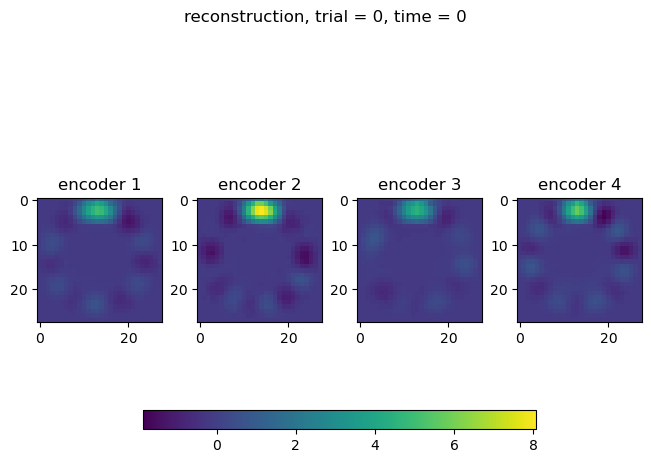

In [91]:
# check reconstruction
trial_check = 0
T_check = 0

X0_back1 = recon_check_x0(encoder1, trial_check, T_check, dset_samples = dset_samples)
X0_back2 = recon_check_x0(encoder2, trial_check, T_check, dset_samples = dset_samples)
X0_back3 = recon_check_x0(encoder3, trial_check, T_check, dset_samples = dset_samples)
X0_back4 = recon_check_x0(encoder4, trial_check, T_check, dset_samples = dset_samples)

fig, axs = plt.subplots(1, 4, constrained_layout=True)
arrs = [X0_back1, X0_back2, X0_back3, X0_back4]
vmin = min(np.min(a) for a in arrs); vmax = max(np.max(a) for a in arrs)
im = axs[0].imshow(X0_back1, vmin=vmin, vmax=vmax); axs[0].set_title('encoder 1')
axs[1].imshow(X0_back2, vmin=vmin, vmax=vmax);       axs[1].set_title('encoder 2')
axs[2].imshow(X0_back3, vmin=vmin, vmax=vmax);       axs[2].set_title('encoder 3')
axs[3].imshow(X0_back4, vmin=vmin, vmax=vmax);       axs[3].set_title('encoder 4')
fig.colorbar(im, ax=axs, orientation='horizontal', fraction=0.06, pad=0.18)
fig.suptitle(f"reconstruction, trial = {trial_check}, time = {T_check}", y=0.96)
plt.show()

# 3. Simulate Trajectories

In [92]:
TRIAL_IDX = 0
n_step = T_max

## 3.1 Data space (tau = 1.0)

In [93]:
tau = 1.0
traj_sim_tau1_flattent, lag_cov_list = generate_traj_image_onthefly(dyn_net4.to(device),
                                                                    dset_samples, n_step,
                                                                    tau, device, lag,
                                                                    include_x0_tau=False,
                                                                    oracle=False,
                                                                    flow_net=None,
                                                                    clamp_range=clamp_range
                                                                    )

100%|███████████████████████████████████████████| 49/49 [00:04<00:00, 12.05it/s]


In [94]:
out_imgs_tau1 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau1_flattent]

/tmp/ipykernel_2332250/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2332250/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


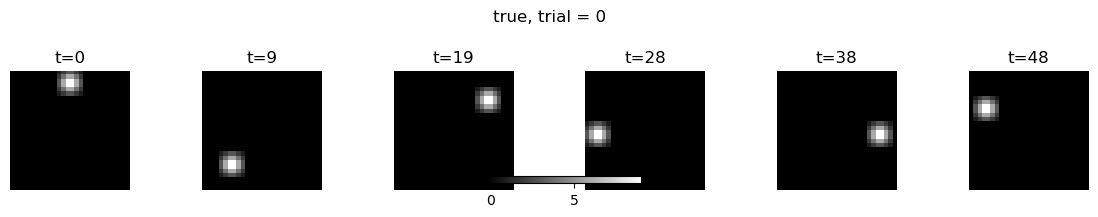

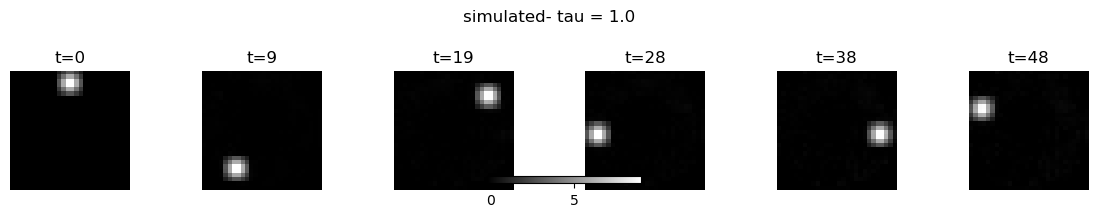

In [95]:
plot_tau(n_step, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

## 3.2 Latent space (tau = 0.0)

In [96]:
out_imgs_tau0_flow_flatten = proj_to_latent(out_imgs_tau1, flow_net4.to(device), 0.0, device)
out_imgs_tau0_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in out_imgs_tau0_flow_flatten ]

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  7.40it/s]


In [97]:
tau = 0.0
traj_sim_tau0_flattent, _ = generate_traj_image_onthefly(dyn_net4.to(device),
                                                         dset_samples, n_step,
                                                         tau, device, lag,
                                                         include_x0_tau=False,
                                                         oracle=False,
                                                         flow_net=flow_net4.to(device),
                                                         clamp_range=clamp_range
                                                         )
out_imgs_tau0 = [arr.reshape(arr.shape[0], C, H, W) for arr in traj_sim_tau0_flattent ]

100%|███████████████████████████████████████████| 49/49 [00:04<00:00, 11.89it/s]


/tmp/ipykernel_2332250/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2332250/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


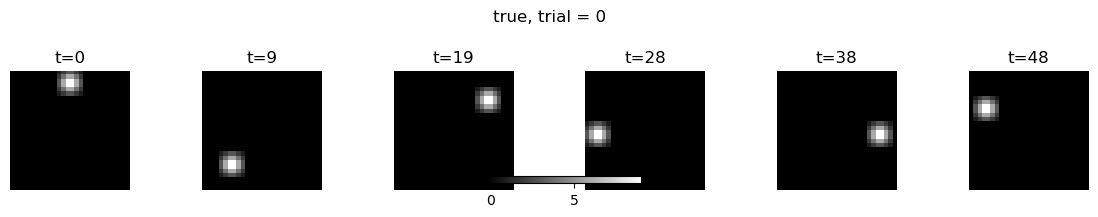

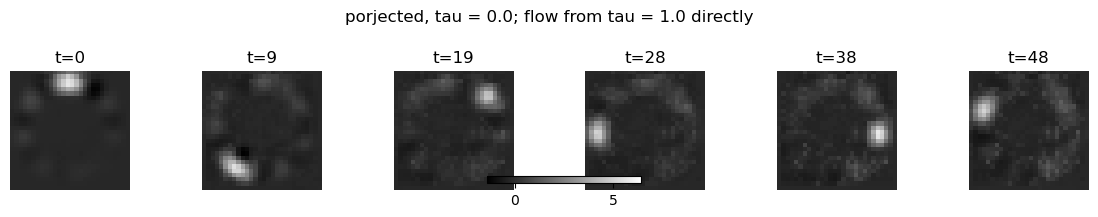

In [98]:
plot_tau(T, out_imgs_tau0_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'porjected, tau = 0.0; flow from tau = 1.0 directly')

/tmp/ipykernel_2332250/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2332250/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


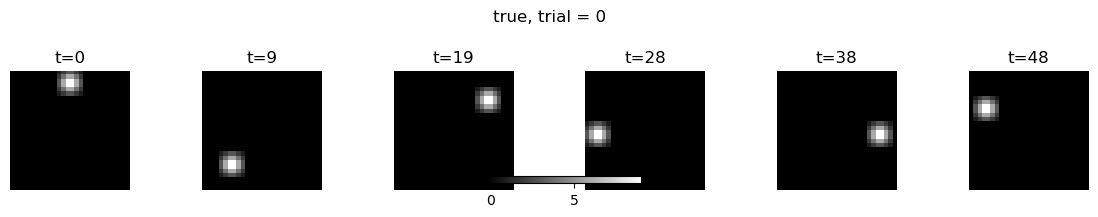

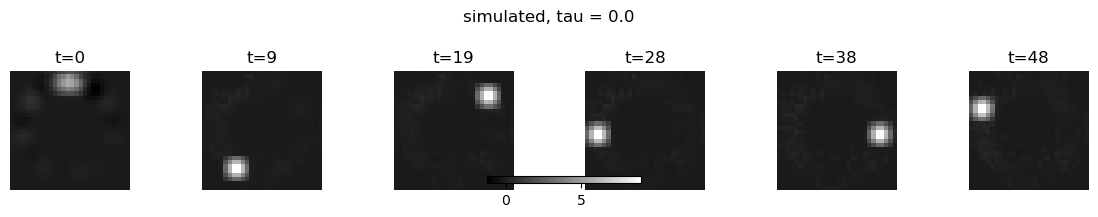

In [99]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0')

# 4. Latent space

In [100]:
data_flattent = [np.reshape(a, (a.shape[0], -1), order='C') for a in dset_samples]

## 4.1 directly from encoder: mu(x_data)

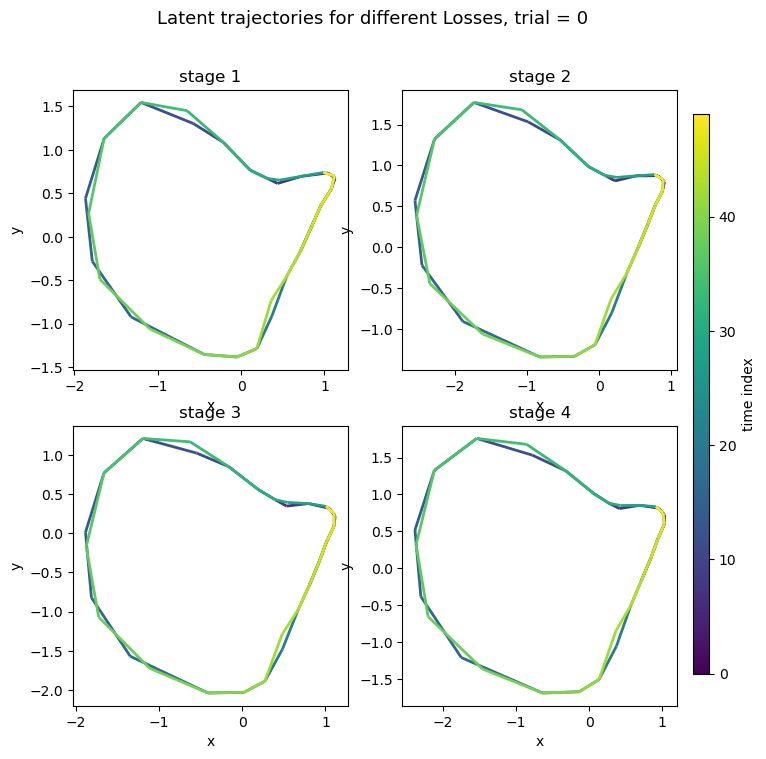

In [101]:
dim_to_keep = 2
mu_keep1 = get_mu_from_encoder(encoder1, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep2 = get_mu_from_encoder(encoder2, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep3 = get_mu_from_encoder(encoder3, data_flattent, dim_to_keep, TRIAL_IDX)
mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
xys     = [mu_keep1, mu_keep2, mu_keep3, mu_keep4]
titles  = ['stage 1', 'stage 2', 'stage 3', 'stage 4']
snap_shot_plot(xys, titles, TRIAL_IDX)

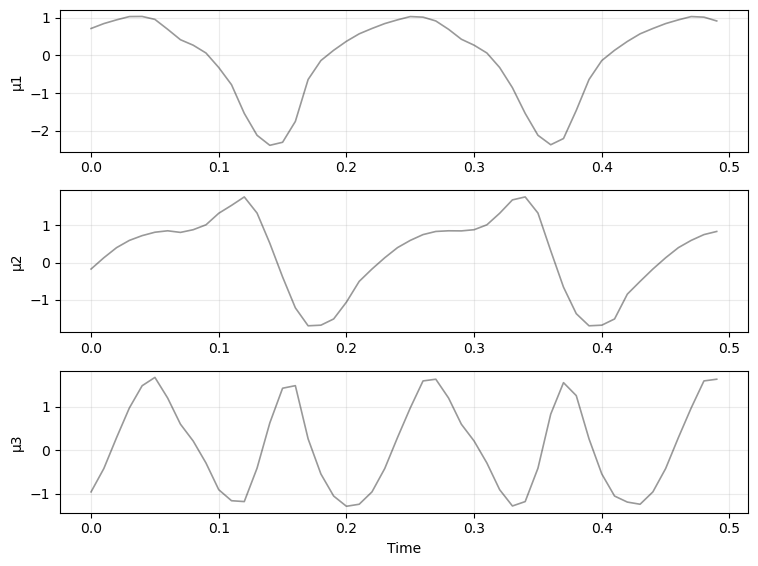

In [102]:
dim_to_keep = 3
mu_keep4 = get_mu_from_encoder(encoder4, data_flattent, dim_to_keep, TRIAL_IDX)
plot_latent_time_series([mu_keep4], alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)

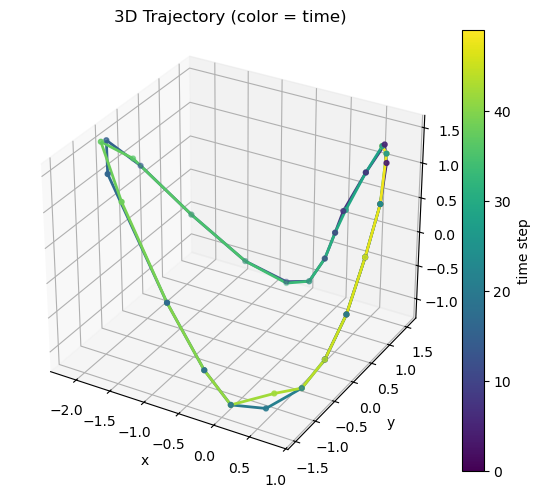

In [103]:
plot_traj_3d(mu_keep4)

In [104]:
_, d, L, loading, bias = latent_mu(dset_samples, encoder4.to(device), dim_to_keep, device, fullRes = True)
L_np = L.detach().cpu().numpy()
d_np = d.detach().cpu().numpy()
loading_np = loading.detach().cpu().numpy()
mu_all = get_mu_from_encoder(encoder4, data_flattent, 28*28, TRIAL_IDX)

Text(0.5, 1.0, 'd')

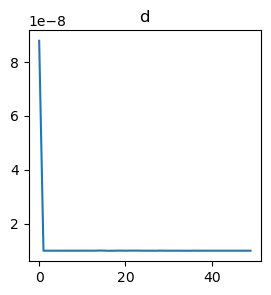

In [105]:
fig = plt.figure(figsize=(3, 3))
plt.plot(d_np[0:50])
plt.title('d')

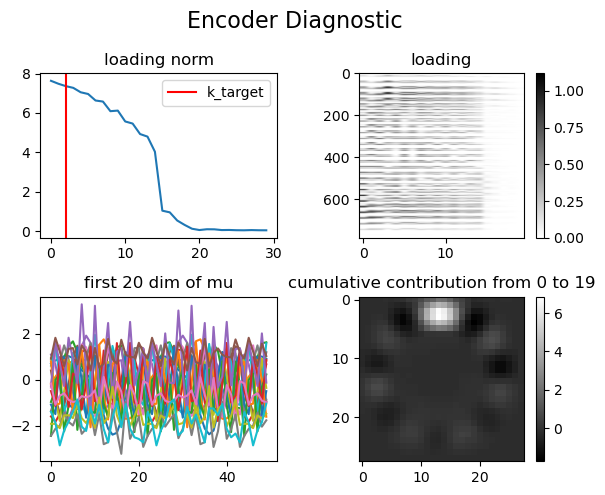

In [106]:
dim_check_most = 20
rows = loading.shape[0]
cols = dim_check_most
dim_check = np.arange(dim_check_most)
rec = mu_group_recon(bias.detach().cpu().numpy(), loading_np, mu_all, dim_check, H=28, W=28)
ball_idx = 0

fig, axs = plt.subplots(2, 2, figsize=(6, 5))

axs[0, 0].plot(torch.norm(loading[:,0:30], dim= 0).detach().cpu().numpy())
axs[0, 0].axvline(x=3-1, color='red', label = 'k_target')
axs[0, 0].set_title('loading norm')
axs[0, 0].legend()

im1 = axs[0, 1].imshow(np.abs(loading_np[:, 0:dim_check_most]), cmap='gray_r', aspect=cols / rows)
axs[0, 1].set_title('loading')
fig.colorbar(im1, ax=axs[0, 1])

axs[1, 0].plot(mu_all[:, :dim_check_most])
axs[1, 0].set_title('first ' + str(dim_check_most) + " dim of mu")

# Plot 4: cumulative contribution
im2 = axs[1, 1].imshow(rec[ball_idx], cmap='gray')
axs[1, 1].set_title('cumulative contribution from ' + str(dim_check[0]) + ' to ' + str(dim_check[-1]))
fig.colorbar(im2, ax=axs[1, 1])

fig.suptitle('Encoder Diagnostic', fontsize=16)
plt.tight_layout()
plt.show()

## 4.2 flowed/ project

In [107]:
dim_to_keep = 3
latent_traj_list = proj_to_latent(dset_samples, flow_net4.to(device), 0.0, device)

100%|███████████████████████████████████████████| 10/10 [00:01<00:00,  8.59it/s]


In [108]:
latent_traj_list_enc = []
for ii in range(len(dset_samples)):
    latent_traj_list_enc.append(recon_check_x0_allT(encoder4, ii, dset_samples))

In [109]:
# mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list_enc, encoder4.to(device), dim_to_keep, device, fullRes = True)
mu_traj_sim, d, L, loading, bias = latent_mu(latent_traj_list, encoder4.to(device), dim_to_keep, device,
                                             fullRes = True, resid_tol=1e-20)

/tmp/ipykernel_2332250/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2332250/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


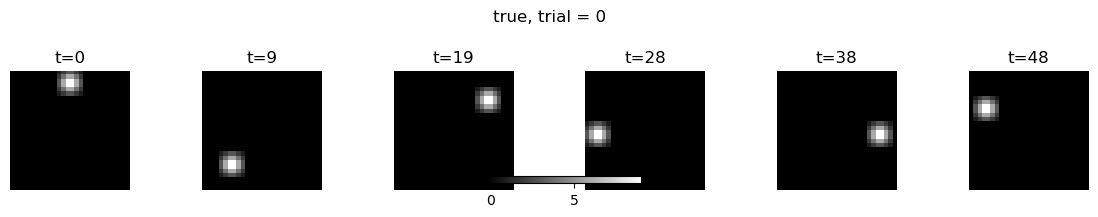

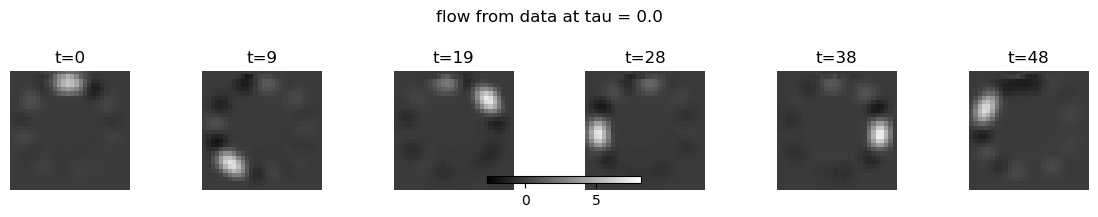

In [110]:
data_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list ]
plot_tau(T, data_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'flow from data at tau = 0.0')

In [111]:
# data_flow = [arr.reshape(arr.shape[0], C, H, W) for arr in latent_traj_list_enc ]
# plot_tau(T, data_flow, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'flow from data at tau = 0.0')

Text(0.5, 0.98, 'flowed latent trajc for each trial')

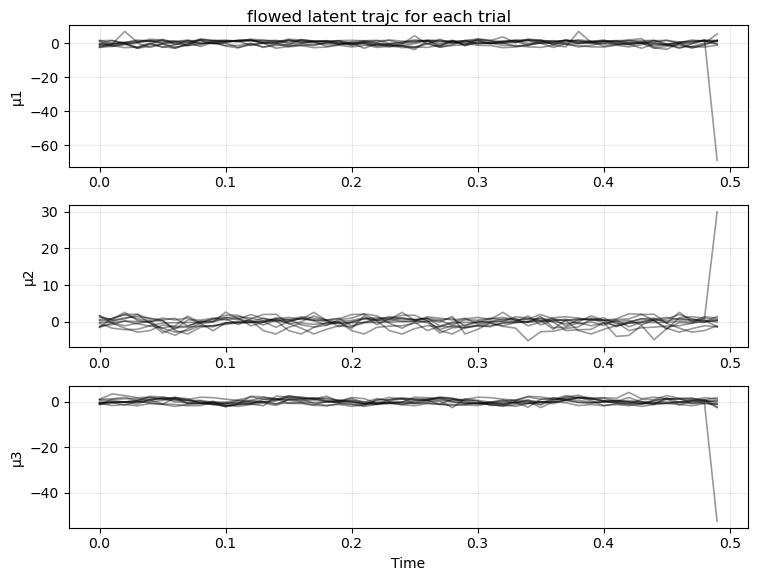

In [112]:
mu_traj_flow_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
plot_latent_time_series(mu_traj_flow_np, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('flowed latent trajc for each trial')

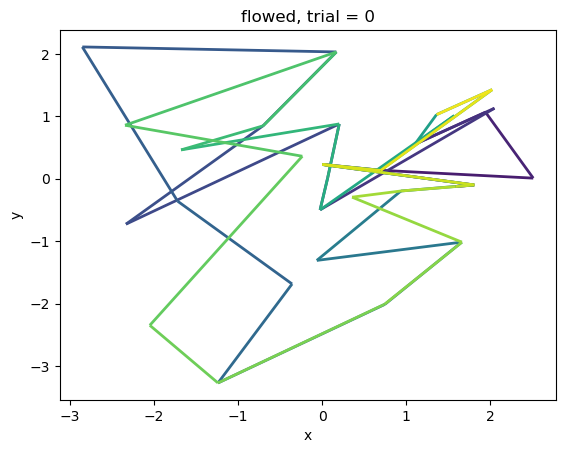

In [113]:
fig, axs = plt.subplots()
norm  = Normalize(vmin=0, vmax=T_max)
plot_latent_2d(axs, mu_traj_flow_np[TRIAL_IDX][:,0:2], norm, 'flowed, trial = ' + str(TRIAL_IDX))

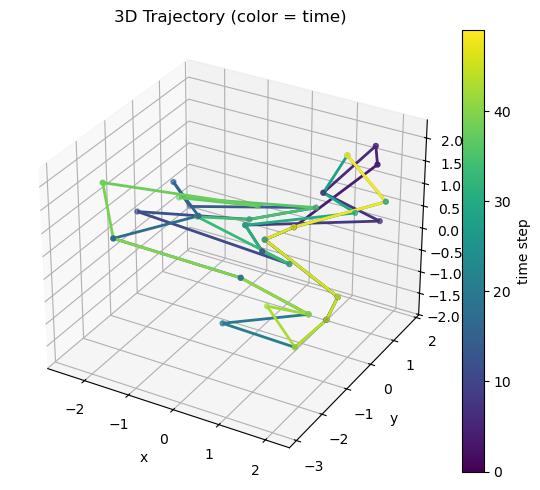

In [114]:
plot_traj_3d(mu_traj_flow_np[TRIAL_IDX][:,0:3])

## 4.3 simulated

In [115]:
dim_to_keep = 3
# data_flattent
mu_traj_sim, d, L, loading, bias = latent_mu(traj_sim_tau0_flattent, encoder4.to(device), dim_to_keep, device, fullRes = True)

Text(0.5, 0.98, 'simulated latent trajc for each trial')

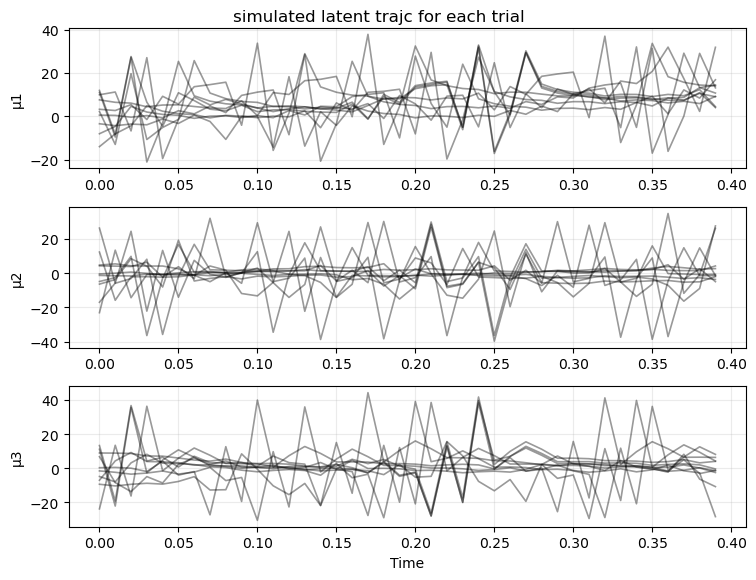

In [116]:
mu_traj_sim_np = [mu_traj_sim[j].cpu().numpy() for j in range(len(mu_traj_sim))]
mu_traj_sim_np_plot = [mu_traj_sim_np[ii][10:,:] for ii in range(len(mu_traj_sim_np))]
plot_latent_time_series(mu_traj_sim_np_plot, alpha = 0.4, dims=np.arange(dim_to_keep), 
                        dt=0.01, labels=None)
plt.suptitle('simulated latent trajc for each trial')

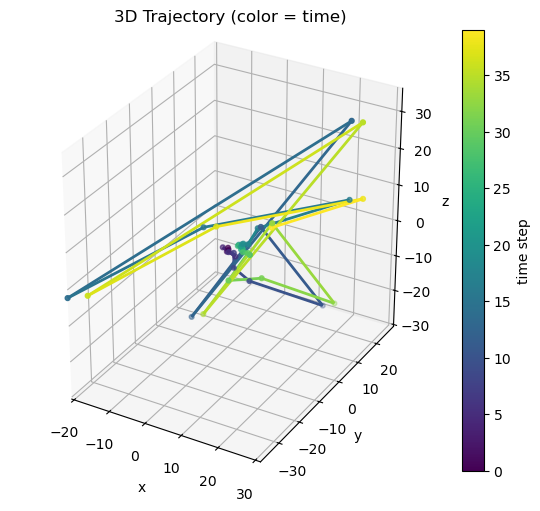

In [117]:
plot_traj_3d(mu_traj_sim_np_plot[TRIAL_IDX][:,0:3])

# Appendix: put all plots together

In [118]:
len(dset_samples)

10

In [119]:
TRIAL_IDX = 9

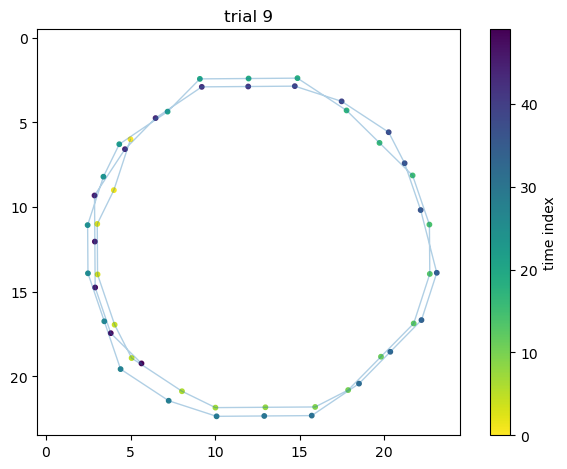

In [120]:
T = T_max
plot_ball_coordinate(TRIAL_IDX, dset_samples, T)

/tmp/ipykernel_2332250/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2332250/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


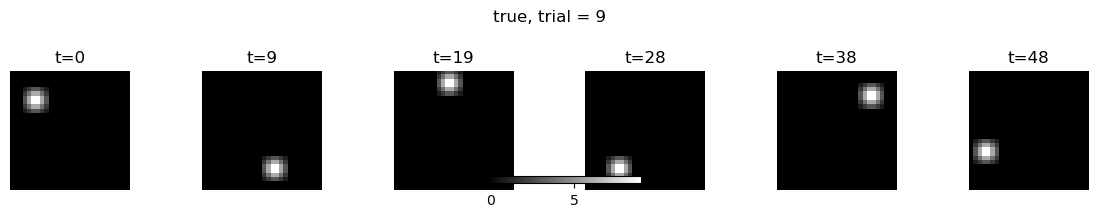

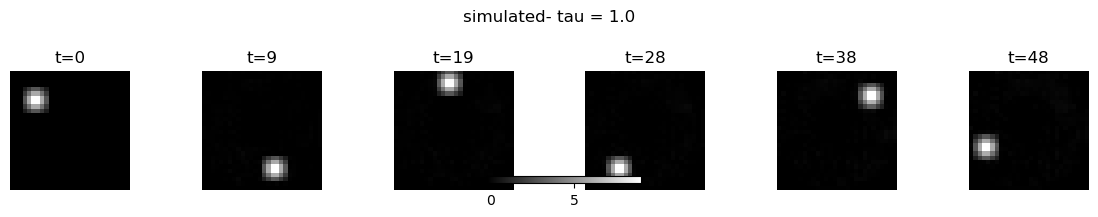

In [121]:
plot_tau(T, out_imgs_tau1, dset_samples, trial_idx = TRIAL_IDX, tau = 1.0)

/tmp/ipykernel_2332250/2225081635.py:4: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_2332250/2225081635.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


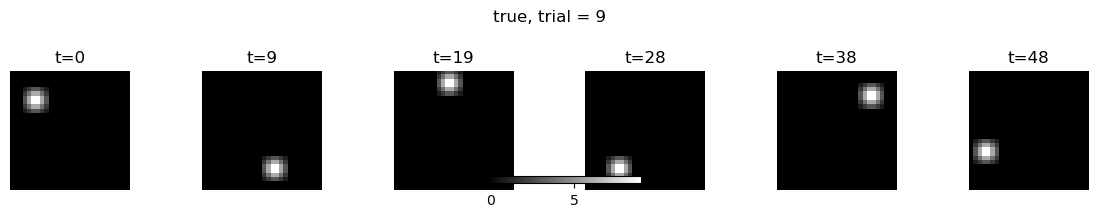

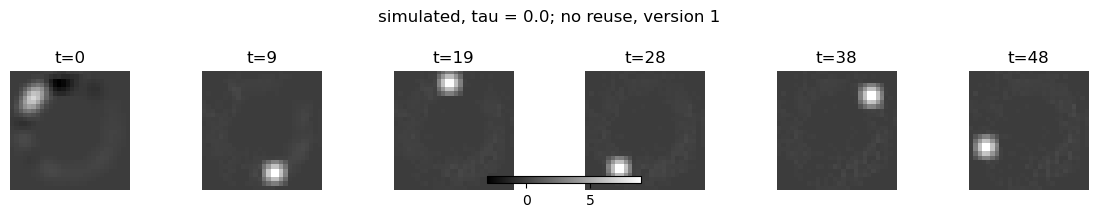

In [122]:
plot_tau(T, out_imgs_tau0, dset_samples, trial_idx = TRIAL_IDX, tau = 0.0, title = 'simulated, tau = 0.0; no reuse, version 1')